# D2 - Tabular Data Project

In aceasta etapa construiesc o solutie completa de machine learning pentru clasificarea tumorilor mamare in doua clase: benigne si maligne.

Scopul este realizarea unui pipeline corect de preprocessing, antrenarea si compararea mai multor modele, evaluarea lor prin metrici adecvate si formularea unor concluzii argumentate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

## Incarcarea datelor

Folosesc acelasi dataset ca in D1, pentru a construi un pipeline complet de clasificare.

In [2]:
df = pd.read_csv("Breast_cancer_Reseach.csv")
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_se,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,2.462022,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,1.592161,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,3.109572,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,3.020457,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,2.027102,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M


## Preprocessing

### Tratarea valorilor lipsa

Din analiza realizata in D1, datasetul nu contine valori lipsa. Prin urmare, nu este necesara imputarea sau eliminarea unor exemple in aceasta etapa.

In [3]:
df.isnull().sum()

radius_mean               0
texture_mean              0
perimeter_mean            0
area_mean                 0
smoothness_mean           0
compactness_mean          0
concavity_mean            0
concave_points_mean       0
symmetry_mean             0
fractal_dimension_mean    0
radius_se                 0
texture_se                0
perimeter_se              0
area_se                   0
smoothness_se             0
radius_worst              0
texture_worst             0
perimeter_worst           0
area_worst                0
concavity_worst           0
concave_points_worst      0
diagnosis                 0
dtype: int64

### Encoding pentru variabila target

Coloana `diagnosis` este categoriala, avand valorile:
- B = benign
- M = malign

Pentru a putea antrena modelele de machine learning, transform aceasta variabila in format numeric:
- B -> 0
- M -> 1

In [4]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
df['diagnosis'].head()

0    0
1    0
2    0
3    1
4    1
Name: diagnosis, dtype: int64

### Verificarea dezechilibrului de clase

Din D1 s-a observat ca distributia claselor este relativ echilibrata. Din acest motiv, nu este necesara aplicarea unor metode suplimentare precum oversampling sau class weights.

In [5]:
df['diagnosis'].value_counts()

diagnosis
0    612
1    588
Name: count, dtype: int64

### Separarea caracteristicilor de variabila target

Separ datele de intrare de variabila pe care vreau sa o prezic.

In [6]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

### Impartirea in set de antrenare si test

Impart datasetul in:
- 80% date pentru antrenare
- 20% date pentru testare

Folosesc "random_state=42" pentru reproductibilitate.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (960, 21)
X_test shape: (240, 21)
y_train shape: (960,)
y_test shape: (240,)


### Standardizarea datelor

In D1 s-a observat ca variabilele au scale diferite. De exemplu, "area_mean" are valori mult mai mari decat "smoothness_mean".

Din acest motiv aplic "StandardScaler", astfel incat modelele sensibile la scala caracteristicilor sa functioneze corect.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1 - Logistic Regression

Am ales Logistic Regression deoarece:
- este un model de baza foarte potrivit pentru clasificare binara
- este usor de interpretat
- functioneaza bine pe date numerice standardizate
- reprezinta un bun punct de referinta pentru comparatia cu celelalte modele

In [9]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

In [10]:
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)

print("Accuracy:", acc_log)
print("Precision:", prec_log)
print("Recall:", rec_log)
print(classification_report(y_test, y_pred_log))

Accuracy: 0.4875
Precision: 0.47572815533980584
Recall: 0.4152542372881356
              precision    recall  f1-score   support

           0       0.50      0.56      0.53       122
           1       0.48      0.42      0.44       118

    accuracy                           0.49       240
   macro avg       0.49      0.49      0.48       240
weighted avg       0.49      0.49      0.48       240



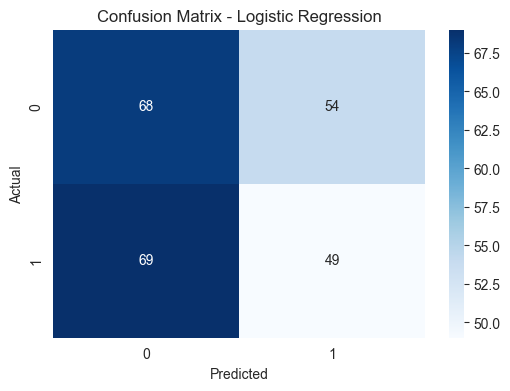

In [11]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression obtine rezultate bune pe acest dataset, ceea ce confirma faptul ca datele sunt bine structurate si separabile. Modelul reprezinta o alegere potrivita pentru clasificarea binara.

## Model 2 - K-Nearest Neighbors

Am ales KNN deoarece:
- este un model clasic de clasificare
- este potrivit pentru date numerice
- este sensibil la distanta, deci beneficiaza de standardizare
- permite comparatia cu un model bazat pe vecinatate, diferit de Logistic Regression

In [12]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [13]:
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)

print("Accuracy:", acc_knn)
print("Precision:", prec_knn)
print("Recall:", rec_knn)
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.5125
Precision: 0.5040650406504065
Recall: 0.5254237288135594
              precision    recall  f1-score   support

           0       0.52      0.50      0.51       122
           1       0.50      0.53      0.51       118

    accuracy                           0.51       240
   macro avg       0.51      0.51      0.51       240
weighted avg       0.51      0.51      0.51       240



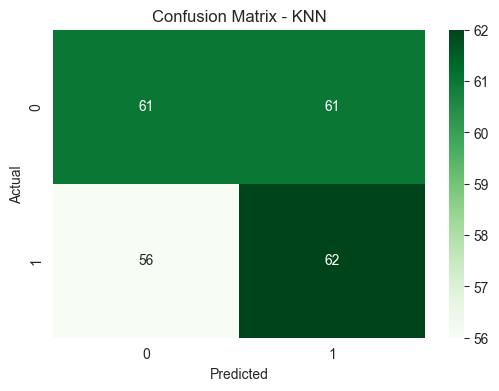

In [14]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN ofera o perspectiva diferita asupra clasificarii, bazandu-se pe vecinii cei mai apropiati. Performanta sa depinde puternic de scala datelor, motiv pentru care standardizarea a fost necesara.

## Model 3 - Random Forest

Am ales Random Forest deoarece:
- este un model ensemble puternic
- poate surprinde relatii mai complexe intre variabile
- este mai robust la outlieri si zgomot
- este util pentru comparatia cu modelele mai simple

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [16]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)

print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.525
Precision: 0.5256410256410257
Recall: 0.3474576271186441
              precision    recall  f1-score   support

           0       0.52      0.70      0.60       122
           1       0.53      0.35      0.42       118

    accuracy                           0.53       240
   macro avg       0.53      0.52      0.51       240
weighted avg       0.53      0.53      0.51       240



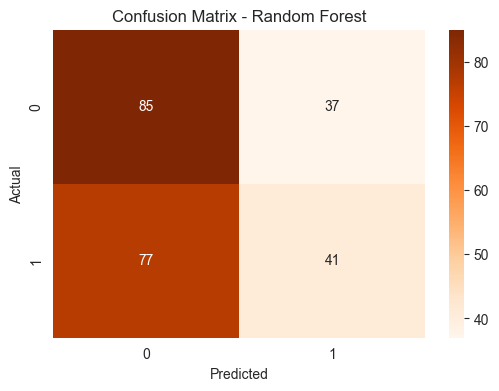

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest este un model mai complex, capabil sa combine mai multi arbori de decizie. In multe cazuri obtine performante foarte bune pe date tabulare, motiv pentru care este un candidat serios pentru modelul final.

## Compararea modelelor

Pentru a decide ce model performeaza cel mai bine, compar rezultatele obtinute de cele trei modele folosind accuracy, precision si recall.

In [18]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [acc_log, acc_knn, acc_rf],
    'Precision': [prec_log, prec_knn, prec_rf],
    'Recall': [rec_log, rec_knn, rec_rf]
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.4875,0.475728,0.415254
1,KNN,0.5125,0.504065,0.525424
2,Random Forest,0.5250,0.525641,0.347458


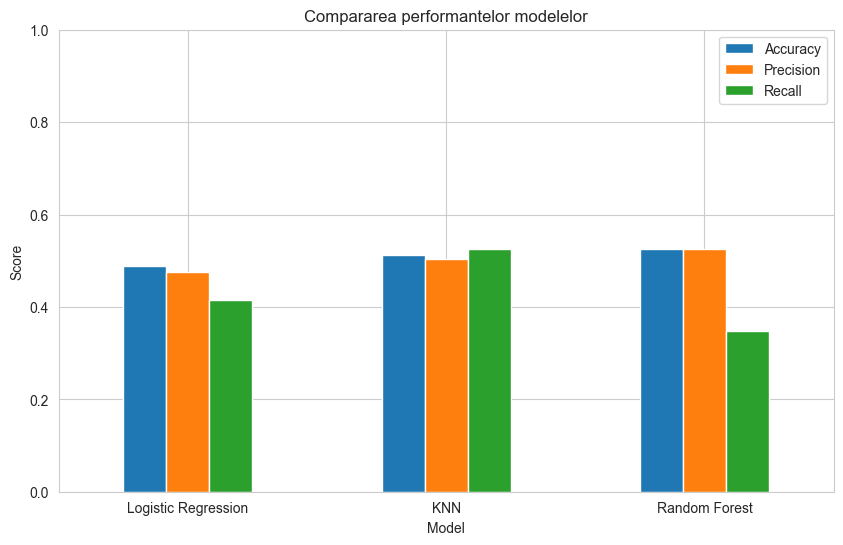

In [19]:
results.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title("Compararea performantelor modelelor")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Concluzii finale

In acest proiect am construit un pipeline complet de machine learning pentru clasificarea tumorilor mamare in benigne si maligne.

Preprocessing-ul a inclus verificarea valorilor lipsa, transformarea variabilei target in format numeric, impartirea datelor in set de antrenare si test si standardizarea caracteristicilor numerice. Acesti pasi au fost necesari pentru a obtine un pipeline corect si reproductibil.

Am comparat trei modele: Logistic Regression, KNN si Random Forest. Dintre acestea, modelul care a obtinut cea mai buna acuratete a fost Random Forest, cu un scor de aproximativ 0.525. KNN a avut rezultate apropiate, iar Logistic Regression a obtinut performante ceva mai slabe. Diferentele dintre modele nu sunt foarte mari, ceea ce sugereaza ca datasetul nu este foarte usor de separat si ca ar putea fi utila o etapa suplimentara de tuning sau selectie de feature-uri.

Desi Random Forest a avut cea mai buna acuratete, KNN a obtinut un recall mai bun pentru clasa pozitiva. Prin urmare, alegerea modelului final poate depinde si de metrica prioritara, nu doar de accuracy.

## Bonus - SVM cu kernel neliniar

Ca experiment suplimentar, testez un model SVM cu kernel RBF, care poate surprinde relatii neliniare intre variabile.

In [20]:
from sklearn.svm import SVC

In [21]:
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm = svm_rbf.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)

print("Accuracy:", acc_svm)
print("Precision:", prec_svm)
print("Recall:", rec_svm)
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.4708333333333333
Precision: 0.46017699115044247
Recall: 0.4406779661016949
              precision    recall  f1-score   support

           0       0.48      0.50      0.49       122
           1       0.46      0.44      0.45       118

    accuracy                           0.47       240
   macro avg       0.47      0.47      0.47       240
weighted avg       0.47      0.47      0.47       240



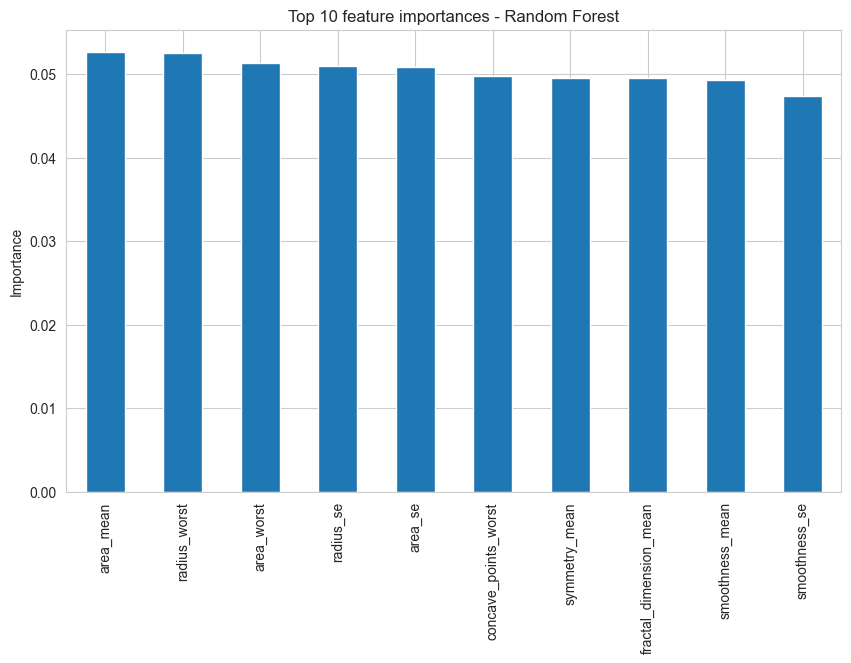

In [22]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.title("Top 10 feature importances - Random Forest")
plt.ylabel("Importance")
plt.show()

Acest grafic evidentiaza cele mai importante caracteristici pentru modelul Random Forest. Vizualizarea ajuta la interpretarea modelului si la intelegerea variabilelor care contribuie cel mai mult la clasificare.